In [17]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "09_ex_con_2025_full_logit_mean_one"


input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'g_stem_res']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)

index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

df = df[df['RMSE_MAX'] < 1.1]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
#df_norm = (dv - dv.mean()) / dv.std()
df_norm = dv
df_norm['sid'] = df['sid']
df_norm['RMSE_MAX'] = df['RMSE_MAX']
df_norm.shape

/tmp/ipykernel_4135235/3185779892.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/tmp/ipykernel_4135235/3185779892.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/tmp/ipykernel_4135235/3185779892.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

(22764, 19)

In [18]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,g_stem_res,sid,RMSE_MAX
42560,-1.365814,2.954224,6982.248649,59.709451,0.000384,-1.261016,-3.706329,-4.733582,0.001036,2.485996,0.000018,-1.378173,0.919762,0.289090,12.107985,1.359060,0.000213,0,0.969696
42561,-0.983038,2.541749,8111.293817,60.133153,0.000406,-1.173778,-4.119473,-5.150188,0.001013,2.774144,0.000021,-2.474775,0.936129,0.260898,9.660008,-1.158298,0.000178,1,0.969696
42564,-1.231994,2.850894,8412.494891,65.833327,0.000372,-1.220123,-3.583278,-4.635473,0.001240,2.491632,0.000007,-1.265337,0.925283,0.239248,9.372908,0.893116,0.000161,4,0.969696
42563,-1.028650,2.713858,8219.168219,47.049758,0.000404,-1.252135,-3.554367,-4.647501,0.001061,2.521060,0.000018,-2.430733,0.987128,0.271715,9.108738,-0.332491,0.000191,3,0.969696
135003,-1.245500,3.694782,11025.387864,103.655803,0.000329,-1.068187,-3.578155,-4.589349,0.001037,2.307406,0.000012,-1.339052,0.949995,0.240995,9.304597,-0.718397,0.000212,3,0.971815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43374,-1.004374,3.092771,5271.515028,135.711756,0.000492,-1.117939,-3.514598,-4.520149,0.000926,2.322683,0.000014,-2.172853,0.913835,0.290255,9.614062,-1.304786,0.000257,4,1.099966
50670,-1.085917,4.576147,9526.975660,148.261401,0.000201,-0.944640,-3.707357,-4.805051,0.001203,2.247273,0.000022,-1.447869,0.978506,0.288962,8.264993,1.104854,0.000272,0,1.099969
50671,-0.826505,5.641016,9995.743689,155.847420,0.000259,-0.960875,-3.812552,-4.960561,0.001188,1.888991,0.000016,-1.628730,0.906942,0.268310,6.265585,-0.486576,0.000222,1,1.099969
50674,-1.162863,6.154179,9900.533347,135.850206,0.000270,-0.949950,-3.514566,-4.551992,0.001249,2.044397,0.000007,-2.235601,0.933693,0.275519,8.395398,0.347607,0.000231,4,1.099969


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

In [20]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

/tmp/ipykernel_4135235/3555042430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['alive'] = 1


In [21]:
imps = []

for i in range(0, 2):
    
    if i == 0:
        svars = vars_all
    else:
        svars = vars_plant
    X_train, X_test, y_train, y_test = train_test_split(df_norm[svars], df_norm['alive'], test_size=0.3, random_state=42)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10, 
        random_state=2909, class_weight='balanced')
    rf.fit(X_train, y_train)
    print(rf.score(X_train, y_train))
    print(rf.score(X_test, y_test))

    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="accuracy",  # we can use any metric
        n_repeats=50,
        random_state=42,
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps.append(importance)


1.0
1.0
0.9730136814359232
0.9449487554904832


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

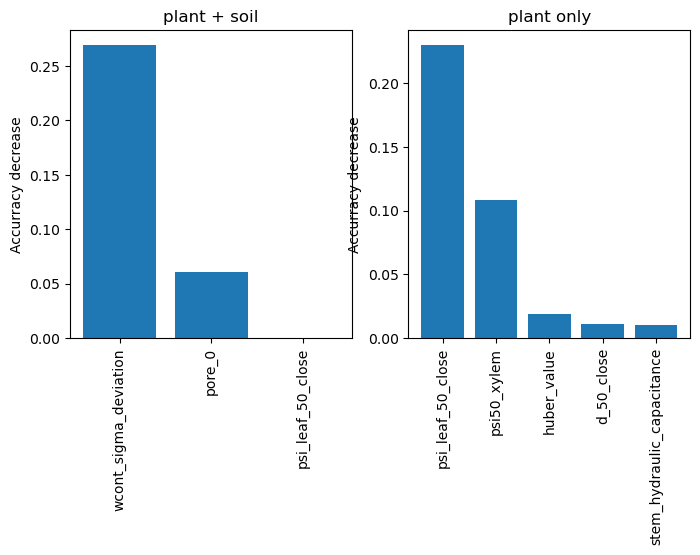

In [22]:
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 4))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
    ax.tick_params(axis='x', labelrotation=90)
    
plt.show()

In [37]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$k_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{close}$"
label_dict['k_soil_sat0'] = r"$k_\mathrm{soil, sat}$"
label_dict['psi_soil_sat0'] = r"$\psi_\mathrm{soil, sat}$"
label_dict['d_50_close'] = r"$d_\mathrm{close}$"

In [24]:
labs = imps[0][0:var_labs_size[i]].index.tolist()

In [25]:
labs_tex = [label_dict[lab] for lab in labs]

In [26]:
labs_tex

['$\\sigma_\\mathrm{wcont}$',
 '$\\xi$',
 '$\\psi_{close, 50}$',
 'd_{close, 50}$',
 '$\\Gamma_\\mathrm{Stem}$']

In [28]:
#labs_all =[r"$\sigma_\mathrm{wcont}$", r"Root $\beta$",r"$g_1$"]

#labs_plant =[ r"Huber", r"$g_0$",r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl, sat}$", r"$\psi_{50}$",r"$\Gamma_\mathrm{Leaf}$"]

/tmp/ipykernel_4135235/115753747.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
/tmp/ipykernel_4135235/115753747.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font

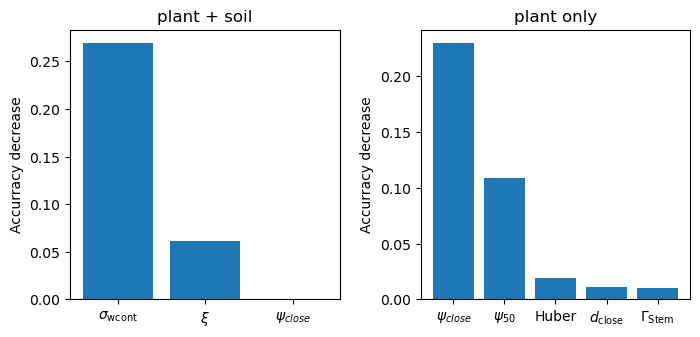

In [38]:
plt.rcParams["font.family"] = "Avenir"
var_labs_size = [3,5]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 3.5))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])

    labs = imps[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)
    

    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F2_RF_classifier.png"), bbox_inches='tight', dpi=300)
plt.show()


In [39]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_all], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))   


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=50,
        random_state=42
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9301503007622016
Root Mean Squared Error (RMSE) train: 0.006217028819692014
Root Mean Squared Error (RMSE) test: 0.016793391702614766
0.8362884954987398
Root Mean Squared Error (RMSE) train: 0.009650173429988555
Root Mean Squared Error (RMSE) test: 0.020148954680717673


In [40]:
imps_regress[0]

,importance_mean,importance_std
psi_leaf_50_close,9.383715e-03,0.000265
d_50_close,6.830313e-03,0.000296
g1,2.618883e-03,0.000187
g0,1.965805e-03,0.000173
k_xylem_sat,1.659462e-03,0.000141
huber_value,6.467451e-04,0.000082
psi_soil_sat0,1.885721e-04,0.000035
stem_hydraulic_capacitance,9.612768e-05,0.000028
k_soil_sat0,5.978983e-05,0.000025
wcont_sigma_deviation,5.768375e-05,0.000026


In [41]:
imps_regress[1]

,importance_mean,importance_std
d_50_close,0.004043,0.000136
psi_leaf_50_close,0.003040,0.000102
g1,0.001585,0.000094
k_xylem_sat,0.001346,0.000100
g0,0.001203,0.000095
huber_value,0.000260,0.000031
stem_hydraulic_capacitance,0.000202,0.000033
g_stem_res,0.000189,0.000031
root_area_index,0.000160,0.000020
leaf_hydraulic_capacitance,0.000096,0.000020


In [44]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$k_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{close}$"
label_dict['d_50_close'] = r"$d_{close}$"
label_dict['g_stem'] = r"$g_\mathrm{Stem,res}$"

/tmp/ipykernel_4135235/2209356565.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
/tmp/ipykernel_4135235/2209356565.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Fo

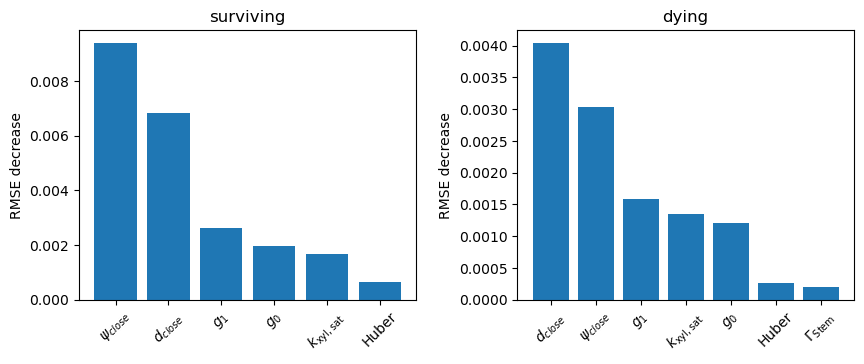

In [45]:
var_labs_size = [6, 7]

title_labs  = ["surviving", "dying"]
fig = plt.figure(figsize=(10, 3.5))
for i in range(0, 2):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps_regress[i][0:var_labs_size[i]].index,imps_regress[i][0:var_labs_size[i]]['importance_mean'])
    labs = imps_regress[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)
    ax.set_title(title_labs[i])
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel("RMSE decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F3_RF_regressor.png"), bbox_inches='tight', dpi=300)
plt.show()

In [39]:
imps_regress[1]

,importance_mean,importance_std
psi_leaf_50_close,0.013253,0.000243
k_xylem_sat,0.009408,0.000274
g1,0.007308,0.000206
huber_value,0.005700,0.000182
d_50_close,0.005183,0.000152
g0,0.001257,0.000070
stem_hydraulic_capacitance,0.000538,0.000038
g_stem_res,0.000209,0.000027
leaf_hydraulic_capacitance,0.000195,0.000028
root_area_index,0.000169,0.000024
